<a href="https://colab.research.google.com/github/Iamfouzia/parkinsons-disease-prediction/blob/main/Parkinson's_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1. Import Libraries & Load Dataset

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
df = pd.read_csv(url)

# Quick look at data
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 2. Exploratory Data Analysis (EDA)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null

/tmp/ipykernel_1444/1921102959.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette='viridis')


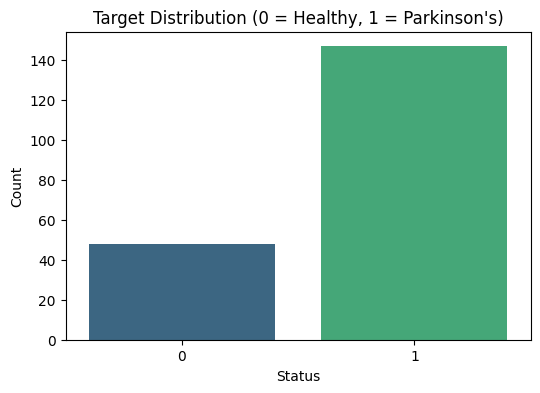

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [23]:
# Info about dataset
print("Dataset Info:")
df.info()

print("\nMissing values:\n", df.isnull().sum().sum())

# Target variable distribution
print("\nTarget variable distribution:")
print(df['status'].value_counts())
print(f"\nPercentage - Parkinson's: {df['status'].value_counts()[1]/len(df)*100:.2f}%")
print(f"Percentage - Healthy: {df['status'].value_counts()[0]/len(df)*100:.2f}%")

# Visualize target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df, palette='viridis')
plt.title('Target Distribution (0 = Healthy, 1 = Parkinson\'s)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

# Statistical summary
df.describe()

# Correlation Heatmap

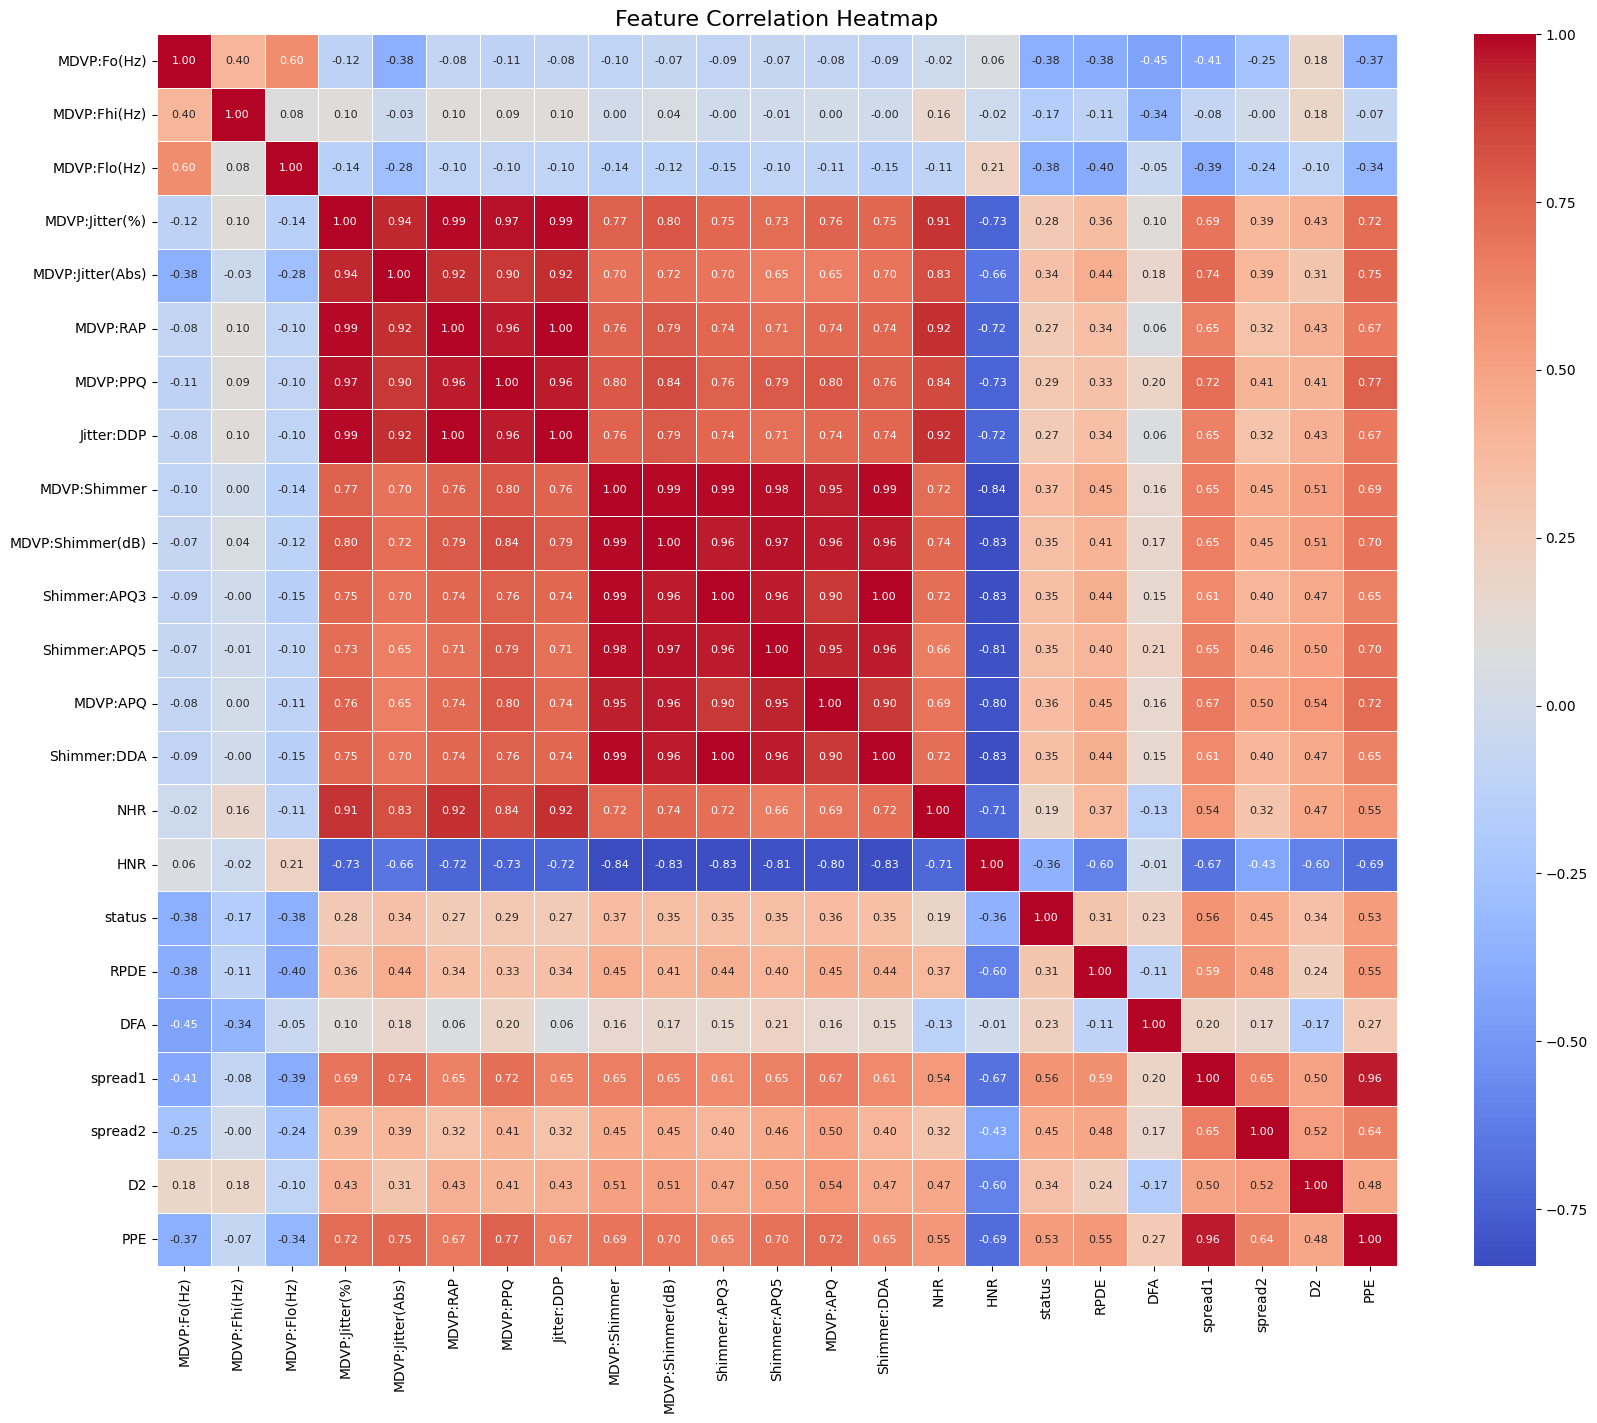

In [24]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={"size": 8}, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

## 3. Data Preprocessing

In [25]:
# Drop 'name' column
df = df.drop('name', axis=1)

# Separate features (X) and target (y)
X = df.drop('status', axis=1)
y = df['status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done. Sample of scaled training data:")
print(X_train_scaled[:2])

Features shape: (195, 22)
Target shape: (195,)

Training set size: 156
Testing set size: 39

Scaling done. Sample of scaled training data:
[[-1.06344643 -0.9157626  -0.33580464 -0.55736615 -0.42216914 -0.54572802
  -0.53371905 -0.5457972  -0.80761002 -0.78182843 -0.81778696 -0.72094174
  -0.68559265 -0.81810818 -0.50697921  1.05569199 -1.27819709  1.0411946
  -0.37859861 -0.42503608 -1.26010198 -0.39131778]
 [ 0.58342091  0.12149404 -0.93052313  0.19156775 -0.150364    0.22668457
   0.20738945  0.22659085  0.84954945  0.67225948  0.9755243   0.92109609
   0.53691262  0.97553705  0.63813485 -1.68978323  0.54036702  0.19346526
   0.36289997  1.44380997  1.76000577  0.35952829]]


## 4. Model Training & Comparison

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Dictionary of models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Train each model and store accuracy
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}%")

# Find best model
best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} with {results[best_model_name]*100:.2f}% accuracy")

Logistic Regression: 92.31%
SVM: 92.31%
Random Forest: 92.31%
KNN: 92.31%

Best Model: Logistic Regression with 92.31% accuracy


## 5. Model Evaluation

Accuracy: 92.31%



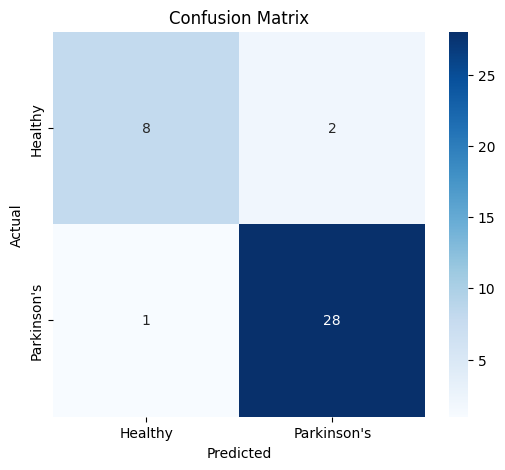

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39

ROC-AUC Score: 0.9621


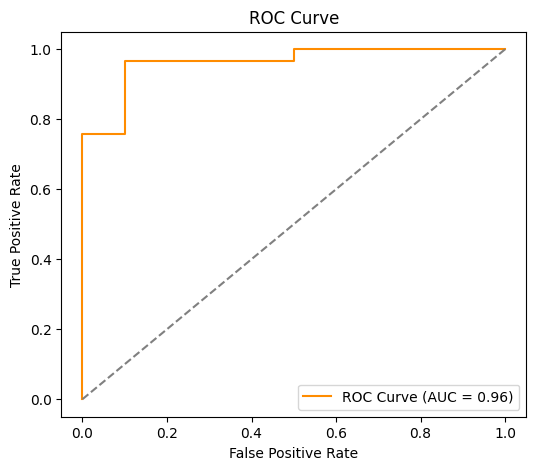

In [27]:

# Train Random Forest
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', "Parkinson's"],
            yticklabels=['Healthy', "Parkinson's"])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Healthy', "Parkinson's"]))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 6. Cross-Validation

In [28]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation on Random Forest
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                              X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation: {cv_scores.std()*100:.2f}%")

Cross-Validation Scores: [0.8125     0.90322581 0.87096774 0.93548387 0.93548387]
Mean CV Accuracy: 89.15%
Standard Deviation: 4.62%


## 6. Hyperparameter Tuning

In [29]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_*100:.2f}%")

# Use the best model found
best_rf_model = grid_search.best_estimator_

# Evaluate on test set
y_pred_best = best_rf_model.predict(X_test_scaled)
print(f"\nTest Accuracy with Best Model: {accuracy_score(y_test, y_pred_best)*100:.2f}%")

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 90.44%

Test Accuracy with Best Model: 92.31%


## 7. Feature Importance Analysis

/tmp/ipykernel_1444/2320844672.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


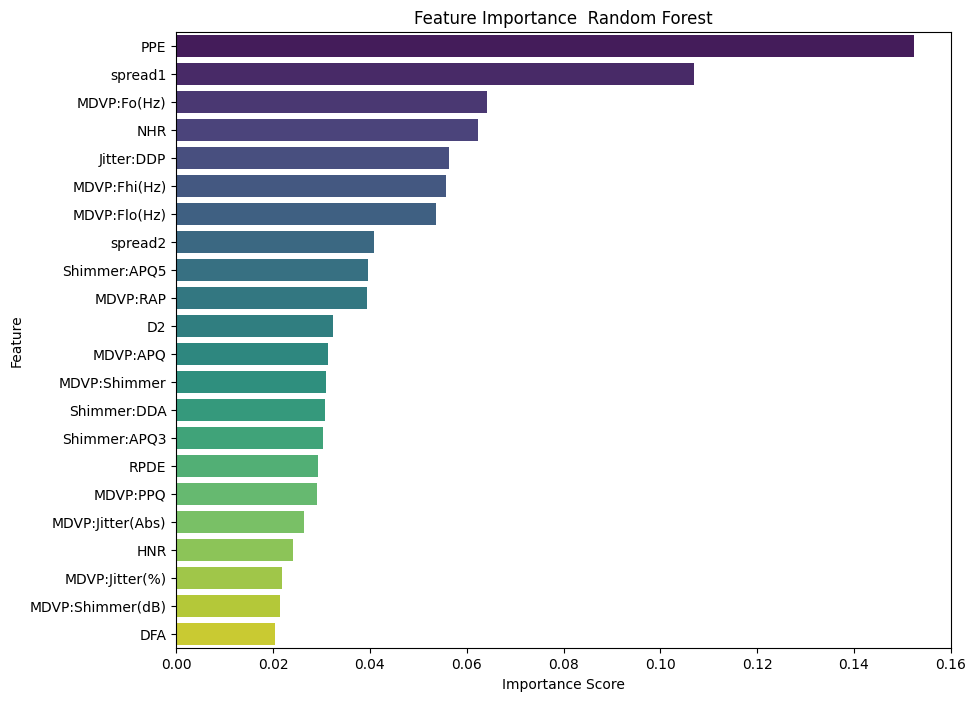

             Feature  Importance
21               PPE    0.152476
18           spread1    0.106974
0        MDVP:Fo(Hz)    0.064174
14               NHR    0.062347
7         Jitter:DDP    0.056404
1       MDVP:Fhi(Hz)    0.055774
2       MDVP:Flo(Hz)    0.053636
19           spread2    0.040810
11      Shimmer:APQ5    0.039663
5           MDVP:RAP    0.039385
20                D2    0.032455
12          MDVP:APQ    0.031318
8       MDVP:Shimmer    0.030897
13       Shimmer:DDA    0.030771
10      Shimmer:APQ3    0.030374
16              RPDE    0.029366
6           MDVP:PPQ    0.029000
4   MDVP:Jitter(Abs)    0.026482
15               HNR    0.024177
3     MDVP:Jitter(%)    0.021814
9   MDVP:Shimmer(dB)    0.021326
17               DFA    0.020375


In [30]:
importances = final_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance  Random Forest')
plt.xlabel('Importance Score')
plt.show()

print(feature_importance_df)

In [31]:
import joblib

# Save the best model (from GridSearchCV)
joblib.dump(best_rf_model, 'parkinsons_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save feature names
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Model, Scaler, and Feature Names saved successfully!")

from google.colab import files
files.download('parkinsons_model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')

Model, Scaler, and Feature Names saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>